# Word Class Prediction with LLM

This notebook trains a language model to predict word classes (Adj, N, V, etc.) given the previous n-1 words in a sentence.

We'll:
1. Generate synthetic text with grammatical structure (no semantic meaning)
2. Split data into uniform and zipfian distributions
3. Train two models (one for each distribution)
4. Evaluate performance with metrics


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random
import json
import os
import nltk

# Download required NLTK data
try:
    nltk.data.find('corpora/brown')
except LookupError:
    print("Downloading Brown corpus...")
    nltk.download('brown', quiet=True)

try:
    nltk.data.find('taggers/universal_tagset')
except LookupError:
    print("Downloading universal tagset...")
    nltk.download('universal_tagset', quiet=True)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [2]:
# Language generation code from language-1.ipynb
# Uses NLTK CFG with Brown corpus words

from nltk import CFG, ChartParser
from nltk.corpus import brown
from nltk.probability import FreqDist
from random import choice, choices
from collections import Counter
import random

# --- Sentence generation with optional Zipf-like sampling ------------------
def produce(grammar, symbol, word_probs=None, use_zipf=False):
    words = []
    productions = grammar.productions(lhs=symbol)
    
    # Choose production - use weighted sampling if use_zipf is enabled
    if word_probs and use_zipf and hasattr(symbol, 'symbol') and symbol.symbol() in word_probs:
        # Get only terminal productions (single string on RHS)
        terminal_prods = [(i, p) for i, p in enumerate(productions) 
                          if len(p.rhs()) == 1 and isinstance(p.rhs()[0], str)]
        
        if terminal_prods:
            # Get words and their probabilities
            indices, prods = zip(*terminal_prods)
            words_list = [p.rhs()[0] for p in prods]
            probs = [word_probs[symbol.symbol()].get(w, 0) for w in words_list]
            
            if sum(probs) > 0:
                # Use weighted choice on terminal productions
                chosen_idx = choices(indices, weights=probs)[0]
                production = productions[chosen_idx]
            else:
                production = choice(productions)
        else:
            production = choice(productions)
    else:
        production = choice(productions)
    
    for sym in production.rhs():
        if isinstance(sym, str):
            words.append(sym)
        else:
            words.extend(produce(grammar, sym, word_probs, use_zipf))
    return words

# --- Build Brown-based word lists -----------------------------------------
print("Loading Brown corpus and building word lists...")
tagged = brown.tagged_words(tagset='universal')

# Collect words by coarse POS
nouns = [w.lower() for w, t in tagged if t == 'NOUN']
verbs = [w.lower() for w, t in tagged if t == 'VERB']
dets  = [w.lower() for w, t in tagged if t == 'DET']
adjs  = [w.lower() for w, t in tagged if t == 'ADJ']
preps = [w.lower() for w, t in tagged if t == 'ADP']

# Use frequency to pick the most common ones (to keep grammar manageable)
def top_clean(words, n):
    fd = FreqDist(words)
    result = []
    for w, _ in fd.most_common():
        if not w.isalpha() or "'" in w or "\\" in w:
            continue
        result.append(w)
        if len(result) >= n:
            break
    return result

top_nouns = top_clean(nouns, 200)
top_verbs = top_clean(verbs, 100)
top_dets  = top_clean(dets, 30)
top_adjs  = top_clean(adjs, 100)
top_preps = top_clean(preps, 50)

# --- Disambiguate words that appear in multiple categories -----------------
word_to_categories = {}
for w in top_nouns:
    word_to_categories.setdefault(w, []).append('N')
for w in top_verbs:
    word_to_categories.setdefault(w, []).append('V')
for w in top_dets:
    word_to_categories.setdefault(w, []).append('Det')
for w in top_adjs:
    word_to_categories.setdefault(w, []).append('Adj')
for w in top_preps:
    word_to_categories.setdefault(w, []).append('P')

def disambiguate_words(words, cat):
    result = []
    for w in words:
        cats = word_to_categories[w]
        if len(cats) > 1:
            result.append(f"{w}({cat})")
        else:
            result.append(w)
    return result

disambig_nouns = disambiguate_words(top_nouns, 'N')
disambig_verbs = disambiguate_words(top_verbs, 'V')
disambig_dets  = disambiguate_words(top_dets, 'Det')
disambig_adjs  = disambiguate_words(top_adjs, 'Adj')
disambig_preps = disambiguate_words(top_preps, 'P')

# --- Assign Zipf-like probabilities to words -------------------------------
def assign_zipf_probabilities(words):
    """Shuffle words, assign prob 1/2, 1/3, 1/4, ..., then normalize"""
    shuffled = words.copy()
    random.shuffle(shuffled)
    
    # Assign 1/(rank+1) probabilities
    raw_probs = [1.0 / (i + 2) for i in range(len(shuffled))]
    
    # Normalize
    total = sum(raw_probs)
    normalized_probs = [p / total for p in raw_probs]
    
    return dict(zip(shuffled, normalized_probs))

word_probs_zipf = {
    'N': assign_zipf_probabilities(disambig_nouns),
    'V': assign_zipf_probabilities(disambig_verbs),
    'Det': assign_zipf_probabilities(disambig_dets),
    'Adj': assign_zipf_probabilities(disambig_adjs),
    'P': assign_zipf_probabilities(disambig_preps),
}

def make_lexical_rules(lhs, words):
    rules = []
    for w in words:
        rules.append(f"{lhs} -> '{w}'")
    return rules

noun_rules = make_lexical_rules("N", disambig_nouns)
verb_rules = make_lexical_rules("V", disambig_verbs)
det_rules  = make_lexical_rules("Det", disambig_dets)
adj_rules  = make_lexical_rules("Adj", disambig_adjs)
prep_rules = make_lexical_rules("P", disambig_preps)

# Map disambiguated word -> POS category (for counting later)
word2cats = {}
def add_mapping(words, cat):
    for w in words:
        word2cats.setdefault(w, set()).add(cat)

add_mapping(disambig_nouns, 'N')
add_mapping(disambig_verbs, 'V')
add_mapping(disambig_dets,  'Det')
add_mapping(disambig_adjs,  'Adj')
add_mapping(disambig_preps, 'P')

# --- Base grammar skeleton (with adjectives) -------------------------------
base_grammar = """
S -> NP VP
PP -> P NP
NP -> Det N | Det Adj N | Det N PP | Det Adj N PP | 'I'
VP -> V NP | VP PP
"""

# Add Brown-derived lexical rules
full_grammar_str = (
    base_grammar
    + "\n"
    + "\n".join(noun_rules + verb_rules + det_rules + adj_rules + prep_rules)
)

grammar = CFG.fromstring(full_grammar_str)
parser = ChartParser(grammar)
gr = parser.grammar()

# --- Generate sentences with word class labels -----------------------------
def get_word_class(word):
    """Get the POS class for a word"""
    # Check if word has disambiguation suffix like "word(N)"
    if '(' in word and ')' in word:
        # Extract category from suffix
        cat = word.split('(')[1].rstrip(')')
        return cat
    # Otherwise look up in word2cats
    w_lower = word.lower()
    cats = word2cats.get(w_lower, set())
    if cats:
        return list(cats)[0]  # Return first category
    return 'OTHER'

def generate_corpus(use_zipf=False, minwords=5, target_sentences=int(1e5), initial_generate=int(1.2e5)):
    """Generate a corpus using the specified word distribution"""
    sentences = []
    sentence_classes = []
    
    word_probs = word_probs_zipf if use_zipf else None
    
    for i in range(initial_generate):
        sent_words = produce(gr, gr.start(), word_probs, use_zipf=use_zipf)
        sent_str = ' '.join(sent_words)
        word_count = len(sent_words)
        
        if word_count >= minwords:
            # Get word classes
            classes = [get_word_class(w) for w in sent_words]
            sentences.append(sent_str)
            sentence_classes.append(classes)
        
        # Stop early if we have enough
        if len(sentences) >= target_sentences:
            break
    
    # Trim to exactly target_sentences
    if len(sentences) > target_sentences:
        sentences = sentences[:target_sentences]
        sentence_classes = sentence_classes[:target_sentences]
    
    return sentences, sentence_classes

# Generate two separate corpora
MINWORDS = 5
TARGET_SENTENCES = int(1e5)  # 100,000 sentences
INITIAL_GENERATE = int(1.2e5)  # Generate 20% more to account for filtering

print("\n" + "="*60)
print("GENERATING UNIFORM CORPUS")
print("="*60)
print(f"Generating corpus with uniform word probabilities...")
print(f"Target: {TARGET_SENTENCES:,} sentences (minimum {MINWORDS} words each)")

uniform_sentences, uniform_classes = generate_corpus(
    use_zipf=False,
    minwords=MINWORDS, 
    target_sentences=TARGET_SENTENCES, 
    initial_generate=INITIAL_GENERATE
)

print(f"\nGenerated {len(uniform_sentences):,} sentences")
print(f"\nExample uniform sentences:")
for i in range(3):
    word_count = len(uniform_sentences[i].split())
    print(f"  {i+1}. {uniform_sentences[i]} ({word_count} words)")

print("\n" + "="*60)
print("GENERATING ZIPFIAN CORPUS")
print("="*60)
print(f"Generating corpus with Zipfian word probabilities...")
print(f"Target: {TARGET_SENTENCES:,} sentences (minimum {MINWORDS} words each)")

zipfian_sentences, zipfian_classes = generate_corpus(
    use_zipf=True,
    minwords=MINWORDS, 
    target_sentences=TARGET_SENTENCES, 
    initial_generate=INITIAL_GENERATE
)

print(f"\nGenerated {len(zipfian_sentences):,} sentences")
print(f"\nExample zipfian sentences:")
for i in range(3):
    word_count = len(zipfian_sentences[i].split())
    print(f"  {i+1}. {zipfian_sentences[i]} ({word_count} words)")

# Store for later use
all_sentences = uniform_sentences  # Default to uniform for backward compatibility
all_sentence_classes = uniform_classes


Loading Brown corpus and building word lists...

GENERATING UNIFORM CORPUS
Generating corpus with uniform word probabilities...
Target: 100,000 sentences (minimum 5 words each)

Generated 100,000 sentences

Example uniform sentences:
  1. her part under I do which tax to those wife except these women while I like(P) every wife (18 words)
  2. I knew his simple word along whose history (8 words)
  3. its less plan among their sure values seem I since I (11 words)

GENERATING ZIPFIAN CORPUS
Generating corpus with Zipfian word probabilities...
Target: 100,000 sentences (minimum 5 words each)

Generated 100,000 sentences

Example zipfian sentences:
  1. its entire word along I needed I (7 words)
  2. its right(Adj) boy although those book following I before both economic board (12 words)
  3. its wife keep whose fire (5 words)


Vocabulary size: 479
Number of classes: 6
Classes: ['Adj', 'Det', 'N', 'OTHER', 'P', 'V']


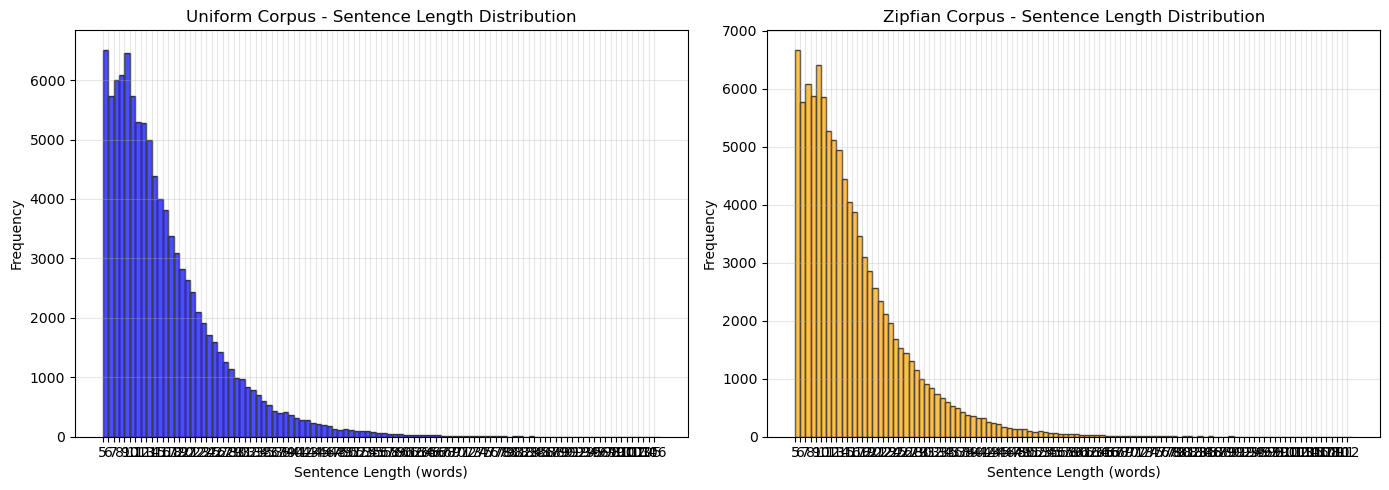


SENTENCE LENGTH STATISTICS

Uniform Corpus:
  Min: 5
  Max: 106
  Mean: 15.73
  Median: 13.00
  Std: 9.90

Zipfian Corpus:
  Min: 5
  Max: 112
  Mean: 15.68
  Median: 13.00
  Std: 9.86


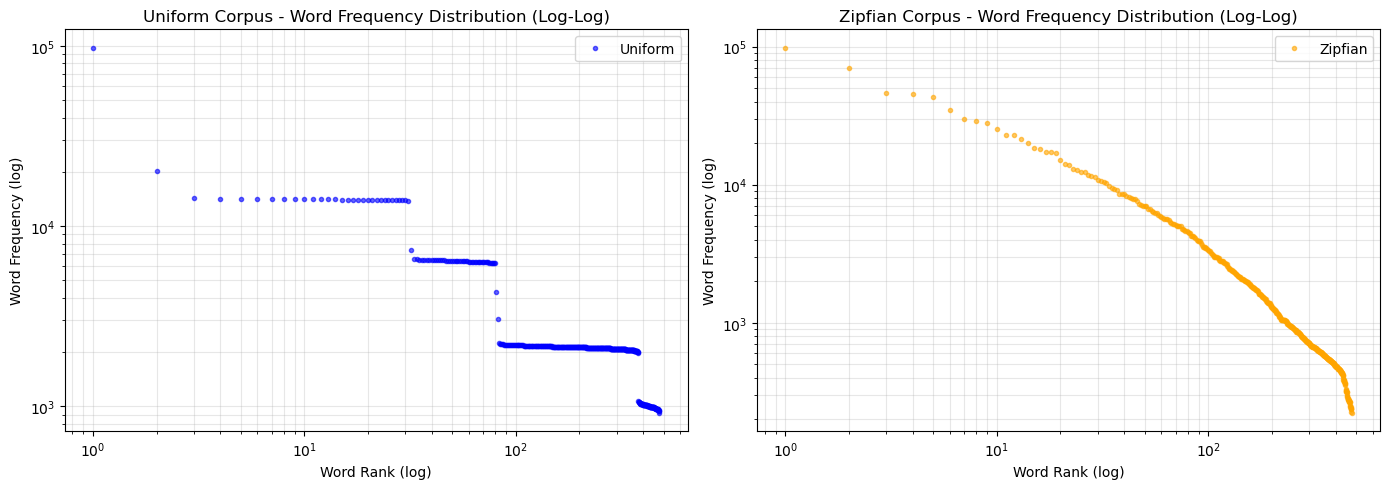


WORD FREQUENCY STATISTICS

Uniform Corpus:
  Unique words: 477
  Total words: 1,573,344
  Most common words:
    I: 97,987
    that: 20,356
    this: 14,274
    some: 14,238
    which: 14,218

Zipfian Corpus:
  Unique words: 477
  Total words: 1,568,388
  Most common words:
    I: 98,277
    its: 69,468
    this: 46,320
    with: 45,284
    sense: 42,963

LAST WORD CLASS DISTRIBUTION

Uniform Corpus - Last Word Class Distribution:
  N: 68,812 (68.81%)
  OTHER: 31,188 (31.19%)

Zipfian Corpus - Last Word Class Distribution:
  N: 68,659 (68.66%)
  OTHER: 31,341 (31.34%)


In [3]:
# Analyze both corpora and create visualizations

# Helper function to clean words (remove disambiguation suffixes)
def clean_word(word):
    """Remove disambiguation suffix like (N) from words"""
    if '(' in word and ')' in word:
        return word.split('(')[0]
    return word

# Analyze uniform corpus
uniform_words = []
for sent in uniform_sentences:
    words = sent.split()
    # Clean words for counting (remove disambiguation suffixes)
    uniform_words.extend([clean_word(w) for w in words])
uniform_word_counter = Counter(uniform_words)
uniform_word_counts = [len(sent.split()) for sent in uniform_sentences]

# Analyze zipfian corpus
zipfian_words = []
for sent in zipfian_sentences:
    words = sent.split()
    # Clean words for counting (remove disambiguation suffixes)
    zipfian_words.extend([clean_word(w) for w in words])
zipfian_word_counter = Counter(zipfian_words)
zipfian_word_counts = [len(sent.split()) for sent in zipfian_sentences]

# Create vocabulary from both corpora (for model training)
all_words = uniform_words + zipfian_words
word_counter = Counter(all_words)
vocab = ['<PAD>', '<UNK>'] + sorted(word_counter.keys())
word_to_idx = {word: idx for idx, word in enumerate(vocab)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

# Class mappings
all_classes = set()
for classes in uniform_classes + zipfian_classes:
    all_classes.update(classes)

class_to_idx = {cls: idx for idx, cls in enumerate(sorted(all_classes))}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

print(f"Vocabulary size: {len(vocab)}")
print(f"Number of classes: {len(class_to_idx)}")
print(f"Classes: {list(class_to_idx.keys())}")

# Plot sentence length distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Uniform corpus sentence length distribution
axes[0].hist(uniform_word_counts, bins=range(min(uniform_word_counts), max(uniform_word_counts)+2), 
             edgecolor='black', alpha=0.7, color='blue')
axes[0].set_xlabel('Sentence Length (words)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Uniform Corpus - Sentence Length Distribution')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(min(uniform_word_counts), max(uniform_word_counts)+1))

# Zipfian corpus sentence length distribution
axes[1].hist(zipfian_word_counts, bins=range(min(zipfian_word_counts), max(zipfian_word_counts)+2), 
             edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Sentence Length (words)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Zipfian Corpus - Sentence Length Distribution')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(min(zipfian_word_counts), max(zipfian_word_counts)+1))

plt.tight_layout()
plt.show()

# Print sentence length statistics
print(f"\n{'='*60}")
print("SENTENCE LENGTH STATISTICS")
print(f"{'='*60}")
print(f"\nUniform Corpus:")
print(f"  Min: {min(uniform_word_counts)}")
print(f"  Max: {max(uniform_word_counts)}")
print(f"  Mean: {np.mean(uniform_word_counts):.2f}")
print(f"  Median: {np.median(uniform_word_counts):.2f}")
print(f"  Std: {np.std(uniform_word_counts):.2f}")

print(f"\nZipfian Corpus:")
print(f"  Min: {min(zipfian_word_counts)}")
print(f"  Max: {max(zipfian_word_counts)}")
print(f"  Mean: {np.mean(zipfian_word_counts):.2f}")
print(f"  Median: {np.median(zipfian_word_counts):.2f}")
print(f"  Std: {np.std(zipfian_word_counts):.2f}")

# Plot word frequency log-log plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Uniform corpus word frequency (log-log)
uniform_freqs = sorted(uniform_word_counter.values(), reverse=True)
uniform_ranks = np.arange(1, len(uniform_freqs) + 1)
axes[0].loglog(uniform_ranks, uniform_freqs, 'o', markersize=3, alpha=0.6, color='blue', label='Uniform')
axes[0].set_xlabel('Word Rank (log)')
axes[0].set_ylabel('Word Frequency (log)')
axes[0].set_title('Uniform Corpus - Word Frequency Distribution (Log-Log)')
axes[0].grid(True, alpha=0.3, which='both')
axes[0].legend()

# Zipfian corpus word frequency (log-log)
zipfian_freqs = sorted(zipfian_word_counter.values(), reverse=True)
zipfian_ranks = np.arange(1, len(zipfian_freqs) + 1)
axes[1].loglog(zipfian_ranks, zipfian_freqs, 'o', markersize=3, alpha=0.6, color='orange', label='Zipfian')
axes[1].set_xlabel('Word Rank (log)')
axes[1].set_ylabel('Word Frequency (log)')
axes[1].set_title('Zipfian Corpus - Word Frequency Distribution (Log-Log)')
axes[1].grid(True, alpha=0.3, which='both')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print word frequency statistics
print(f"\n{'='*60}")
print("WORD FREQUENCY STATISTICS")
print(f"{'='*60}")
print(f"\nUniform Corpus:")
print(f"  Unique words: {len(uniform_word_counter)}")
print(f"  Total words: {sum(uniform_word_counter.values()):,}")
print(f"  Most common words:")
for word, count in uniform_word_counter.most_common(5):
    print(f"    {word}: {count:,}")

print(f"\nZipfian Corpus:")
print(f"  Unique words: {len(zipfian_word_counter)}")
print(f"  Total words: {sum(zipfian_word_counter.values()):,}")
print(f"  Most common words:")
for word, count in zipfian_word_counter.most_common(5):
    print(f"    {word}: {count:,}")

# Calculate distribution of last word classes for both corpora
print(f"\n{'='*60}")
print("LAST WORD CLASS DISTRIBUTION")
print(f"{'='*60}")

# Get last word class for each sentence
uniform_last_classes = [classes[-1] if len(classes) > 0 else 'OTHER' for classes in uniform_classes]
zipfian_last_classes = [classes[-1] if len(classes) > 0 else 'OTHER' for classes in zipfian_classes]

# Count occurrences
uniform_last_class_counter = Counter(uniform_last_classes)
zipfian_last_class_counter = Counter(zipfian_last_classes)

# Calculate percentages
total_uni = len(uniform_last_classes)
total_zip = len(zipfian_last_classes)

print(f"\nUniform Corpus - Last Word Class Distribution:")
for class_name in sorted(uniform_last_class_counter.keys()):
    count = uniform_last_class_counter[class_name]
    percentage = (count / total_uni) * 100
    print(f"  {class_name}: {count:,} ({percentage:.2f}%)")

print(f"\nZipfian Corpus - Last Word Class Distribution:")
for class_name in sorted(zipfian_last_class_counter.keys()):
    count = zipfian_last_class_counter[class_name]
    percentage = (count / total_zip) * 100
    print(f"  {class_name}: {count:,} ({percentage:.2f}%)")

# For backward compatibility, use uniform corpus as default
all_sentences = uniform_sentences
all_sentence_classes = uniform_classes


In [4]:
# Prepare data: for each sentence, create (n-1 words, last word class) pairs
def prepare_data(sentences, sentence_classes, n=5):
    """Prepare data: take first n-1 words, predict class of nth word"""
    X = []  # Sequences of n-1 words
    y = []  # Class of nth word
    
    for sent, classes in zip(sentences, sentence_classes):
        words = sent.split()
        if len(words) >= n:
            # Take first n-1 words, predict class of nth word
            sequence = words[:n-1]
            target_class = classes[n-1]
            
            # Clean words and convert to indices
            cleaned_sequence = [clean_word(w) for w in sequence]
            seq_indices = [word_to_idx.get(w, word_to_idx['<UNK>']) for w in cleaned_sequence]
            class_idx = class_to_idx.get(target_class, class_to_idx.get('OTHER', 0))
            
            X.append(seq_indices)
            y.append(class_idx)
    
    return np.array(X), np.array(y)

# Use n=5 (predict 5th word class from first 4 words)
n_context = 5

# Prepare data for uniform corpus
X_uni, y_uni = prepare_data(uniform_sentences, uniform_classes, n=n_context)
print(f"Uniform corpus - Total samples: {len(X_uni)}")

# Prepare data for zipfian corpus
X_zip, y_zip = prepare_data(zipfian_sentences, zipfian_classes, n=n_context)
print(f"Zipfian corpus - Total samples: {len(X_zip)}")

print(f"\nSequence length (n-1): {n_context - 1}")
print(f"Number of classes: {len(class_to_idx)}")

# For backward compatibility, use uniform corpus
X, y = X_uni, y_uni
all_sentences = uniform_sentences
all_sentence_classes = uniform_classes


Uniform corpus - Total samples: 100000
Zipfian corpus - Total samples: 100000

Sequence length (n-1): 4
Number of classes: 6


In [5]:
# Split data into uniform and zipfian distributions and save corpora

def create_uniform_split(X, y, sentences, sentence_classes, train_ratio=0.8):
    """Split data uniformly (random split)"""
    indices = np.arange(len(X))
    train_idx, val_idx = train_test_split(indices, test_size=1-train_ratio, random_state=42, stratify=y)
    
    # Extract sentences for each split
    train_sentences = [sentences[i] for i in train_idx]
    train_classes = [sentence_classes[i] for i in train_idx]
    val_sentences = [sentences[i] for i in val_idx]
    val_classes = [sentence_classes[i] for i in val_idx]
    
    return (X[train_idx], X[val_idx], y[train_idx], y[val_idx], 
            train_sentences, val_sentences, train_classes, val_classes)

def create_zipfian_split(X, y, sentences, sentence_classes, train_ratio=0.8):
    """Split data following Zipfian distribution (frequent items in train, rare in val)"""
    # Calculate word frequencies
    word_freqs = Counter()
    for seq in X:
        for word_idx in seq:
            word_freqs[word_idx] += 1
    
    # Sort by frequency (most frequent first)
    sorted_words = sorted(word_freqs.items(), key=lambda x: x[1], reverse=True)
    
    # Assign frequent words to train, rare to val
    n_train_words = int(len(sorted_words) * train_ratio)
    train_words = set([word_idx for word_idx, _ in sorted_words[:n_train_words]])
    
    # Split samples based on whether they contain mostly train or val words
    train_indices = []
    val_indices = []
    
    for idx, seq in enumerate(X):
        # Count how many words in sequence are in train set
        train_word_count = sum(1 for word_idx in seq if word_idx in train_words)
        if train_word_count >= len(seq) / 2:  # Majority are train words
            train_indices.append(idx)
        else:
            val_indices.append(idx)
    
    # Ensure we have enough samples in each set
    if len(train_indices) < len(X) * 0.7:
        # Fallback: use frequency-based sampling
        word_freq_array = np.array([word_freqs.get(w, 0) for w in range(len(vocab))])
        seq_freqs = np.array([np.mean([word_freq_array[w] for w in seq]) for seq in X])
        sorted_indices = np.argsort(seq_freqs)[::-1]  # Most frequent first
        n_train = int(len(X) * train_ratio)
        train_indices = sorted_indices[:n_train].tolist()
        val_indices = sorted_indices[n_train:].tolist()
    
    # Extract sentences for each split
    train_sentences = [sentences[i] for i in train_indices]
    train_classes = [sentence_classes[i] for i in train_indices]
    val_sentences = [sentences[i] for i in val_indices]
    val_classes = [sentence_classes[i] for i in val_indices]
    
    return (X[train_indices], X[val_indices], y[train_indices], y[val_indices],
            train_sentences, val_sentences, train_classes, val_classes)

# Create splits for uniform corpus (using uniform split)
print("Creating train/val split for uniform corpus...")
X_train_uni, X_val_uni, y_train_uni, y_val_uni, train_sent_uni, val_sent_uni, train_class_uni, val_class_uni = \
    create_uniform_split(X_uni, y_uni, uniform_sentences, uniform_classes, train_ratio=0.8)

# Create splits for zipfian corpus (using uniform split for train/val)
print("Creating train/val split for zipfian corpus...")
X_train_zip, X_val_zip, y_train_zip, y_val_zip, train_sent_zip, val_sent_zip, train_class_zip, val_class_zip = \
    create_uniform_split(X_zip, y_zip, zipfian_sentences, zipfian_classes, train_ratio=0.8)

print(f"\nUniform split:")
print(f"  Train: {len(X_train_uni)} samples")
print(f"  Val: {len(X_val_uni)} samples")

print(f"\nZipfian split:")
print(f"  Train: {len(X_train_zip)} samples")
print(f"  Val: {len(X_val_zip)} samples")

# Check class distributions
print(f"\nUniform train class distribution:")
uni_train_counts = Counter(y_train_uni)
for class_idx in sorted(uni_train_counts.keys()):
    print(f"  {idx_to_class[class_idx]}: {uni_train_counts[class_idx]}")

print(f"\nZipfian train class distribution:")
zip_train_counts = Counter(y_train_zip)
for class_idx in sorted(zip_train_counts.keys()):
    print(f"  {idx_to_class[class_idx]}: {zip_train_counts[class_idx]}")

# Save corpora to files
output_dir = "corpora"
os.makedirs(output_dir, exist_ok=True)

# Save uniform corpus (full corpus, not just train/val split)
uniform_corpus = {
    'sentences': uniform_sentences,
    'classes': uniform_classes,
    'train': {
        'sentences': train_sent_uni,
        'classes': train_class_uni
    },
    'val': {
        'sentences': val_sent_uni,
        'classes': val_class_uni
    },
    'metadata': {
        'total_sentences': len(uniform_sentences),
        'train_sentences': len(train_sent_uni),
        'val_sentences': len(val_sent_uni),
        'min_words': MINWORDS,
        'word_distribution': 'uniform'
    }
}

# Save zipfian corpus (full corpus, not just train/val split)
zipfian_corpus = {
    'sentences': zipfian_sentences,
    'classes': zipfian_classes,
    'train': {
        'sentences': train_sent_zip,
        'classes': train_class_zip
    },
    'val': {
        'sentences': val_sent_zip,
        'classes': val_class_zip
    },
    'metadata': {
        'total_sentences': len(zipfian_sentences),
        'train_sentences': len(train_sent_zip),
        'val_sentences': len(val_sent_zip),
        'min_words': MINWORDS,
        'word_distribution': 'zipfian'
    }
}

# Save as JSON
uniform_path = os.path.join(output_dir, 'uniform_corpus.json')
zipfian_path = os.path.join(output_dir, 'zipfian_corpus.json')

with open(uniform_path, 'w', encoding='utf-8') as f:
    json.dump(uniform_corpus, f, ensure_ascii=False, indent=2)

with open(zipfian_path, 'w', encoding='utf-8') as f:
    json.dump(zipfian_corpus, f, ensure_ascii=False, indent=2)

# Also save as plain text files (one sentence per line)
uniform_full_txt = os.path.join(output_dir, 'uniform_full.txt')
uniform_train_txt = os.path.join(output_dir, 'uniform_train.txt')
uniform_val_txt = os.path.join(output_dir, 'uniform_val.txt')
zipfian_full_txt = os.path.join(output_dir, 'zipfian_full.txt')
zipfian_train_txt = os.path.join(output_dir, 'zipfian_train.txt')
zipfian_val_txt = os.path.join(output_dir, 'zipfian_val.txt')

# Save full corpora
with open(uniform_full_txt, 'w', encoding='utf-8') as f:
    f.write('\n'.join(uniform_sentences))

with open(zipfian_full_txt, 'w', encoding='utf-8') as f:
    f.write('\n'.join(zipfian_sentences))

# Save train/val splits
with open(uniform_train_txt, 'w', encoding='utf-8') as f:
    f.write('\n'.join(train_sent_uni))

with open(uniform_val_txt, 'w', encoding='utf-8') as f:
    f.write('\n'.join(val_sent_uni))

with open(zipfian_train_txt, 'w', encoding='utf-8') as f:
    f.write('\n'.join(train_sent_zip))

with open(zipfian_val_txt, 'w', encoding='utf-8') as f:
    f.write('\n'.join(val_sent_zip))

print(f"\n{'='*60}")
print("CORPORA SAVED")
print(f"{'='*60}")
print(f"Uniform corpus (uniform word probabilities):")
print(f"  JSON: {uniform_path}")
print(f"  Full text: {uniform_full_txt} ({len(uniform_sentences):,} sentences)")
print(f"  Train text: {uniform_train_txt} ({len(train_sent_uni):,} sentences)")
print(f"  Val text: {uniform_val_txt} ({len(val_sent_uni):,} sentences)")
print(f"\nZipfian corpus (zipfian word probabilities):")
print(f"  JSON: {zipfian_path}")
print(f"  Full text: {zipfian_full_txt} ({len(zipfian_sentences):,} sentences)")
print(f"  Train text: {zipfian_train_txt} ({len(train_sent_zip):,} sentences)")
print(f"  Val text: {zipfian_val_txt} ({len(val_sent_zip):,} sentences)")


Creating train/val split for uniform corpus...
Creating train/val split for zipfian corpus...

Uniform split:
  Train: 80000 samples
  Val: 20000 samples

Zipfian split:
  Train: 80000 samples
  Val: 20000 samples

Uniform train class distribution:
  Adj: 13479
  Det: 28569
  N: 20499
  OTHER: 7117
  P: 6939
  V: 3397

Zipfian train class distribution:
  Adj: 13523
  Det: 28624
  N: 20492
  OTHER: 7179
  P: 6759
  V: 3423

CORPORA SAVED
Uniform corpus (uniform word probabilities):
  JSON: corpora/uniform_corpus.json
  Full text: corpora/uniform_full.txt (100,000 sentences)
  Train text: corpora/uniform_train.txt (80,000 sentences)
  Val text: corpora/uniform_val.txt (20,000 sentences)

Zipfian corpus (zipfian word probabilities):
  JSON: corpora/zipfian_corpus.json
  Full text: corpora/zipfian_full.txt (100,000 sentences)
  Train text: corpora/zipfian_train.txt (80,000 sentences)
  Val text: corpora/zipfian_val.txt (20,000 sentences)


In [6]:
# Dataset class
class WordClassDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset_uni = WordClassDataset(X_train_uni, y_train_uni)
val_dataset_uni = WordClassDataset(X_val_uni, y_val_uni)
train_dataset_zip = WordClassDataset(X_train_zip, y_train_zip)
val_dataset_zip = WordClassDataset(X_val_zip, y_val_zip)

# Data loaders
batch_size = 64
train_loader_uni = DataLoader(train_dataset_uni, batch_size=batch_size, shuffle=True)
val_loader_uni = DataLoader(val_dataset_uni, batch_size=batch_size, shuffle=False)
train_loader_zip = DataLoader(train_dataset_zip, batch_size=batch_size, shuffle=True)
val_loader_zip = DataLoader(val_dataset_zip, batch_size=batch_size, shuffle=False)


In [22]:
# Define the Language Model (smaller architecture for this task)
class WordClassPredictor(nn.Module):
    def __init__(self, vocab_size, embedding_dim=32, hidden_dim=64, num_classes=6, num_layers=1):
        super(WordClassPredictor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # No dropout in LSTM when num_layers=1
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True, dropout=0.0)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(0.2)  # Reduced dropout for smaller model
    
    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        lstm_out, _ = self.lstm(embedded)  # (batch_size, seq_len, hidden_dim)
        # Take the last output
        last_hidden = lstm_out[:, -1, :]  # (batch_size, hidden_dim)
        last_hidden = self.dropout(last_hidden)
        output = self.fc(last_hidden)  # (batch_size, num_classes)
        return output

# Initialize models (smaller architecture)
vocab_size = len(vocab)
num_classes = len(class_to_idx)

# Reduced model size: embedding_dim=32, hidden_dim=64, num_layers=1
model_uni = WordClassPredictor(vocab_size, embedding_dim=32, hidden_dim=64, 
                               num_classes=num_classes, num_layers=1).to(device)
model_zip = WordClassPredictor(vocab_size, embedding_dim=32, hidden_dim=64, 
                               num_classes=num_classes, num_layers=1).to(device)

print(f"Model architecture (reduced size):")
print(f"  Vocabulary size: {vocab_size}")
print(f"  Embedding dim: 32 (reduced from 128)")
print(f"  Hidden dim: 64 (reduced from 256)")
print(f"  Number of layers: 1 (reduced from 2)")
print(f"  Number of classes: {num_classes}")
print(f"  Number of parameters (uniform model): {sum(p.numel() for p in model_uni.parameters()):,}")
print(f"  (Previous model had ~984K parameters)")


Model architecture (reduced size):
  Vocabulary size: 479
  Embedding dim: 32 (reduced from 128)
  Hidden dim: 64 (reduced from 256)
  Number of layers: 1 (reduced from 2)
  Number of classes: 6
  Number of parameters (uniform model): 40,806
  (Previous model had ~984K parameters)


In [24]:
# Check what untrained model predicts (before any training)
print("="*60)
print("UNTRAINED MODEL PREDICTIONS")
print("="*60)

from collections import Counter

# Check uniform model
model_uni.eval()
with torch.no_grad():
    # Get a sample batch from validation set
    sample_X, sample_y = next(iter(val_loader_uni))
    sample_X = sample_X.to(device)
    outputs = model_uni(sample_X)
    _, predicted = torch.max(outputs, 1)
    
    # Calculate accuracy
    untrained_acc = 100 * (predicted == sample_y.to(device)).sum().item() / len(sample_y)
    
    # Count predictions
    pred_counts = Counter(predicted.cpu().numpy())
    actual_counts = Counter(sample_y.numpy())
    
    print(f"\nUniform Model (Untrained):")
    print(f"  Accuracy on sample batch: {untrained_acc:.2f}%")
    print(f"  Predicted class distribution:")
    for class_idx in sorted(pred_counts.keys()):
        class_name = idx_to_class[class_idx]
        count = pred_counts[class_idx]
        pct = 100 * count / len(predicted)
        print(f"    {class_name}: {count} ({pct:.1f}%)")
    print(f"  Actual class distribution in sample:")
    for class_idx in sorted(actual_counts.keys()):
        class_name = idx_to_class[class_idx]
        count = actual_counts[class_idx]
        pct = 100 * count / len(sample_y)
        print(f"    {class_name}: {count} ({pct:.1f}%)")

# Check zipfian model
model_zip.eval()
with torch.no_grad():
    sample_X, sample_y = next(iter(val_loader_zip))
    sample_X = sample_X.to(device)
    outputs = model_zip(sample_X)
    _, predicted = torch.max(outputs, 1)
    
    untrained_acc = 100 * (predicted == sample_y.to(device)).sum().item() / len(sample_y)
    
    pred_counts = Counter(predicted.cpu().numpy())
    actual_counts = Counter(sample_y.numpy())
    
    print(f"\nZipfian Model (Untrained):")
    print(f"  Accuracy on sample batch: {untrained_acc:.2f}%")
    print(f"  Predicted class distribution:")
    for class_idx in sorted(pred_counts.keys()):
        class_name = idx_to_class[class_idx]
        count = pred_counts[class_idx]
        pct = 100 * count / len(predicted)
        print(f"    {class_name}: {count} ({pct:.1f}%)")
    print(f"  Actual class distribution in sample:")
    for class_idx in sorted(actual_counts.keys()):
        class_name = idx_to_class[class_idx]
        count = actual_counts[class_idx]
        pct = 100 * count / len(sample_y)
        print(f"    {class_name}: {count} ({pct:.1f}%)")

# Full validation set evaluation for untrained models
print(f"\n{'='*60}")
print("FULL VALIDATION SET EVALUATION (UNTRAINED)")
print(f"{'='*60}")

# Uniform model
model_uni.eval()
untrained_correct_uni = 0
untrained_total_uni = 0
untrained_pred_dist_uni = Counter()

with torch.no_grad():
    for batch_X, batch_y in val_loader_uni:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model_uni(batch_X)
        _, predicted = torch.max(outputs, 1)
        untrained_total_uni += batch_y.size(0)
        untrained_correct_uni += (predicted == batch_y).sum().item()
        untrained_pred_dist_uni.update(predicted.cpu().numpy())

untrained_acc_uni = 100 * untrained_correct_uni / untrained_total_uni
print(f"\nUniform Model (Untrained) - Full Validation Set:")
print(f"  Accuracy: {untrained_acc_uni:.2f}%")
print(f"  Predicted class distribution:")
for class_idx in sorted(untrained_pred_dist_uni.keys()):
    class_name = idx_to_class[class_idx]
    count = untrained_pred_dist_uni[class_idx]
    pct = 100 * count / untrained_total_uni
    print(f"    {class_name}: {count:,} ({pct:.2f}%)")

# Zipfian model
model_zip.eval()
untrained_correct_zip = 0
untrained_total_zip = 0
untrained_pred_dist_zip = Counter()

with torch.no_grad():
    for batch_X, batch_y in val_loader_zip:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model_zip(batch_X)
        _, predicted = torch.max(outputs, 1)
        untrained_total_zip += batch_y.size(0)
        untrained_correct_zip += (predicted == batch_y).sum().item()
        untrained_pred_dist_zip.update(predicted.cpu().numpy())

untrained_acc_zip = 100 * untrained_correct_zip / untrained_total_zip
print(f"\nZipfian Model (Untrained) - Full Validation Set:")
print(f"  Accuracy: {untrained_acc_zip:.2f}%")
print(f"  Predicted class distribution:")
for class_idx in sorted(untrained_pred_dist_zip.keys()):
    class_name = idx_to_class[class_idx]
    count = untrained_pred_dist_zip[class_idx]
    pct = 100 * count / untrained_total_zip
    print(f"    {class_name}: {count:,} ({pct:.2f}%)")

print(f"\n{'='*60}")
print("NOTE: This shows what the model predicts with random initialization.")
print("If accuracy is already ~74%, it means the model learns very quickly!")
print(f"{'='*60}")

# Set models back to train mode for training
model_uni.train()
model_zip.train()


UNTRAINED MODEL PREDICTIONS

Uniform Model (Untrained):
  Accuracy on sample batch: 6.25%
  Predicted class distribution:
    Det: 5 (7.8%)
    N: 22 (34.4%)
    OTHER: 16 (25.0%)
    P: 1 (1.6%)
    V: 20 (31.2%)
  Actual class distribution in sample:
    Adj: 12 (18.8%)
    Det: 26 (40.6%)
    N: 14 (21.9%)
    OTHER: 4 (6.2%)
    P: 7 (10.9%)
    V: 1 (1.6%)

Zipfian Model (Untrained):
  Accuracy on sample batch: 9.38%
  Predicted class distribution:
    Det: 1 (1.6%)
    OTHER: 41 (64.1%)
    P: 19 (29.7%)
    V: 3 (4.7%)
  Actual class distribution in sample:
    Adj: 8 (12.5%)
    Det: 31 (48.4%)
    N: 12 (18.8%)
    OTHER: 2 (3.1%)
    P: 8 (12.5%)
    V: 3 (4.7%)

FULL VALIDATION SET EVALUATION (UNTRAINED)

Uniform Model (Untrained) - Full Validation Set:
  Accuracy: 13.94%
  Predicted class distribution:
    Adj: 70 (0.35%)
    Det: 2,218 (11.09%)
    N: 5,939 (29.70%)
    OTHER: 5,890 (29.45%)
    P: 438 (2.19%)
    V: 5,445 (27.23%)

Zipfian Model (Untrained) - Full Validat

WordClassPredictor(
  (embedding): Embedding(479, 32)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=6, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

In [28]:
# Training function
def train_model(model, train_loader, val_loader, num_epochs=6, lr=0.001, model_name="model", 
                val_eval_frequency=50):
    """
    Train model with first-epoch batch-level tracking.
    
    Args:
        val_eval_frequency: Evaluate validation every N batches during first epoch (default: 50)
                           Lower values = more frequent but slower. Higher values = faster but less detailed.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    # Track per-batch metrics during first epoch
    first_epoch_batch_train_losses = []
    first_epoch_batch_train_accs = []
    first_epoch_batch_val_losses = []
    first_epoch_batch_val_accs = []
    
    best_val_acc = 0.0
    best_model_state = None
    
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")
    print(f"First epoch: Evaluating validation every {val_eval_frequency} batches")
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        batch_count = 0
        total_batches = len(train_loader)
        
        for batch_idx, (batch_X, batch_y) in enumerate(train_loader):
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            batch_loss = loss.item()
            train_loss += batch_loss
            batch_count += 1
            
            # Track per-batch metrics during first epoch
            if epoch == 0:
                first_epoch_batch_train_losses.append(batch_loss)
                
                # Calculate batch accuracy
                _, predicted = torch.max(outputs.data, 1)
                batch_acc = 100 * (predicted == batch_y).sum().item() / batch_y.size(0)
                first_epoch_batch_train_accs.append(batch_acc)
                
                # Evaluate on validation set every N batches (not every batch!)
                should_eval_val = (batch_idx + 1) % val_eval_frequency == 0 or batch_idx == 0
                
                if should_eval_val:
                    model.eval()
                    val_loss_batch = 0.0
                    val_correct = 0
                    val_total = 0
                    
                    with torch.no_grad():
                        for val_batch_X, val_batch_y in val_loader:
                            val_batch_X, val_batch_y = val_batch_X.to(device), val_batch_y.to(device)
                            val_outputs = model(val_batch_X)
                            val_loss_b = criterion(val_outputs, val_batch_y)
                            val_loss_batch += val_loss_b.item()
                            
                            _, val_predicted = torch.max(val_outputs.data, 1)
                            val_total += val_batch_y.size(0)
                            val_correct += (val_predicted == val_batch_y).sum().item()
                    
                    val_loss_batch /= len(val_loader)
                    val_acc_batch = 100 * val_correct / val_total
                    first_epoch_batch_val_losses.append(val_loss_batch)
                    first_epoch_batch_val_accs.append(val_acc_batch)
                    
                    # Progress printing
                    print(f"  Epoch 1 - Batch {batch_idx + 1}/{total_batches}: "
                          f"Train Loss: {batch_loss:.4f}, Val Loss: {val_loss_batch:.4f}, Val Acc: {val_acc_batch:.2f}%")
                    
                    model.train()  # Switch back to training mode
                else:
                    # For batches without validation evaluation, reuse last validation metrics
                    if len(first_epoch_batch_val_losses) > 0:
                        first_epoch_batch_val_losses.append(first_epoch_batch_val_losses[-1])
                        first_epoch_batch_val_accs.append(first_epoch_batch_val_accs[-1])
                    else:
                        # First batch should always evaluate, but just in case
                        first_epoch_batch_val_losses.append(None)
                        first_epoch_batch_val_accs.append(None)
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total += batch_y.size(0)
                correct += (predicted == batch_y).sum().item()
        
        val_loss /= len(val_loader)
        val_acc = 100 * correct / total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        scheduler.step(val_loss)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Load best model
    model.load_state_dict(best_model_state)
    print(f"\nBest validation accuracy: {best_val_acc:.2f}%")
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies,
        'best_val_acc': best_val_acc,
        'first_epoch_batch_train_losses': first_epoch_batch_train_losses,
        'first_epoch_batch_train_accs': first_epoch_batch_train_accs,
        'first_epoch_batch_val_losses': first_epoch_batch_val_losses,
        'first_epoch_batch_val_accs': first_epoch_batch_val_accs
    }

# Train both models with multiple random initializations
num_runs = 20
print(f"Training models with {num_runs} different random initializations...")
print("This will take longer but gives more reliable averaged results.\n")

# Storage for all runs
all_results_uni = []
all_results_zip = []

for run in range(num_runs):
    print(f"\n{'='*60}")
    print(f"RUN {run + 1}/{num_runs}")
    print(f"{'='*60}")
    
    # Set different random seed for each run
    run_seed = 42 + run
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    random.seed(run_seed)
    
    # Create new models with different initialization
    model_uni = WordClassPredictor(vocab_size, embedding_dim=32, hidden_dim=64, 
                                   num_classes=num_classes, num_layers=1).to(device)
    model_zip = WordClassPredictor(vocab_size, embedding_dim=32, hidden_dim=64, 
                                   num_classes=num_classes, num_layers=1).to(device)
    
    # Train models (only 1 epoch, tracking first epoch batches)
    result_uni = train_model(model_uni, train_loader_uni, val_loader_uni, 
                             num_epochs=1, lr=0.001, 
                             model_name=f"Uniform Model (Run {run+1}/{num_runs})",
                             val_eval_frequency=50)
    result_zip = train_model(model_zip, train_loader_zip, val_loader_zip, 
                             num_epochs=1, lr=0.001, 
                             model_name=f"Zipfian Model (Run {run+1}/{num_runs})",
                             val_eval_frequency=50)
    
    all_results_uni.append(result_uni)
    all_results_zip.append(result_zip)
    
    print(f"Run {run+1} complete - Uniform final val acc: {result_uni['val_accuracies'][-1]:.2f}%, "
          f"Zipfian final val acc: {result_zip['val_accuracies'][-1]:.2f}%")

print(f"\n{'='*60}")
print(f"ALL {num_runs} RUNS COMPLETE")
print(f"{'='*60}")

# Average the results
def average_batch_metrics(all_results):
    """Average first epoch batch metrics across all runs"""
    # Find the maximum length (in case runs have slightly different batch counts)
    max_len = max(len(r['first_epoch_batch_train_losses']) for r in all_results)
    
    # Initialize arrays for averaging
    avg_train_losses = np.zeros(max_len)
    avg_train_accs = np.zeros(max_len)
    avg_val_losses = np.zeros(max_len)
    avg_val_accs = np.zeros(max_len)
    counts_train = np.zeros(max_len)
    counts_val = np.zeros(max_len)
    
    # Sum across all runs
    for result in all_results:
        train_losses = result['first_epoch_batch_train_losses']
        train_accs = result['first_epoch_batch_train_accs']
        val_losses = result['first_epoch_batch_val_losses']
        val_accs = result['first_epoch_batch_val_accs']
        
        for i in range(len(train_losses)):
            if train_losses[i] is not None:
                avg_train_losses[i] += train_losses[i]
                counts_train[i] += 1
            if train_accs[i] is not None:
                avg_train_accs[i] += train_accs[i]
        
        for i in range(len(val_losses)):
            if val_losses[i] is not None:
                avg_val_losses[i] += val_losses[i]
                counts_val[i] += 1
            if i < len(val_accs) and val_accs[i] is not None:
                avg_val_accs[i] += val_accs[i]
    
    # Average (avoid division by zero)
    avg_train_losses = np.where(counts_train > 0, avg_train_losses / counts_train, 0)
    avg_train_accs = np.where(counts_train > 0, avg_train_accs / counts_train, 0)
    avg_val_losses = np.where(counts_val > 0, avg_val_losses / counts_val, 0)
    avg_val_accs = np.where(counts_val > 0, avg_val_accs / counts_val, 0)
    
    return {
        'first_epoch_batch_train_losses': avg_train_losses.tolist(),
        'first_epoch_batch_train_accs': avg_train_accs.tolist(),
        'first_epoch_batch_val_losses': avg_val_losses.tolist(),
        'first_epoch_batch_val_accs': avg_val_accs.tolist()
    }

# Create averaged results
results_uni = average_batch_metrics(all_results_uni)
results_zip = average_batch_metrics(all_results_zip)

# Also average the per-epoch metrics
results_uni['val_accuracies'] = [np.mean([r['val_accuracies'][0] for r in all_results_uni])]
results_uni['val_losses'] = [np.mean([r['val_losses'][0] for r in all_results_uni])]
results_zip['val_accuracies'] = [np.mean([r['val_accuracies'][0] for r in all_results_zip])]
results_zip['val_losses'] = [np.mean([r['val_losses'][0] for r in all_results_zip])]

print(f"\nAveraged results computed across {num_runs} runs")
print(f"Uniform Model - Average final val acc: {results_uni['val_accuracies'][-1]:.2f}%")
print(f"Zipfian Model - Average final val acc: {results_zip['val_accuracies'][-1]:.2f}%")


Training models with 20 different random initializations...
This will take longer but gives more reliable averaged results.


RUN 1/20

Training Uniform Model (Run 1/20)
First epoch: Evaluating validation every 50 batches
  Epoch 1 - Batch 1/1250: Train Loss: 1.7852, Val Loss: 1.7988, Val Acc: 12.62%
  Epoch 1 - Batch 50/1250: Train Loss: 1.5896, Val Loss: 1.5361, Val Acc: 40.66%
  Epoch 1 - Batch 100/1250: Train Loss: 1.3055, Val Loss: 1.2540, Val Acc: 51.97%
  Epoch 1 - Batch 150/1250: Train Loss: 0.9162, Val Loss: 0.9957, Val Acc: 58.02%
  Epoch 1 - Batch 200/1250: Train Loss: 0.8356, Val Loss: 0.8270, Val Acc: 62.48%
  Epoch 1 - Batch 250/1250: Train Loss: 0.7873, Val Loss: 0.7237, Val Acc: 64.44%
  Epoch 1 - Batch 300/1250: Train Loss: 0.6289, Val Loss: 0.6645, Val Acc: 66.42%
  Epoch 1 - Batch 350/1250: Train Loss: 0.7209, Val Loss: 0.6336, Val Acc: 67.20%
  Epoch 1 - Batch 400/1250: Train Loss: 0.5287, Val Loss: 0.6130, Val Acc: 68.02%
  Epoch 1 - Batch 450/1250: Train Loss: 0.5


FIRST EPOCH BATCH-LEVEL METRICS (Averaged across 20 runs)


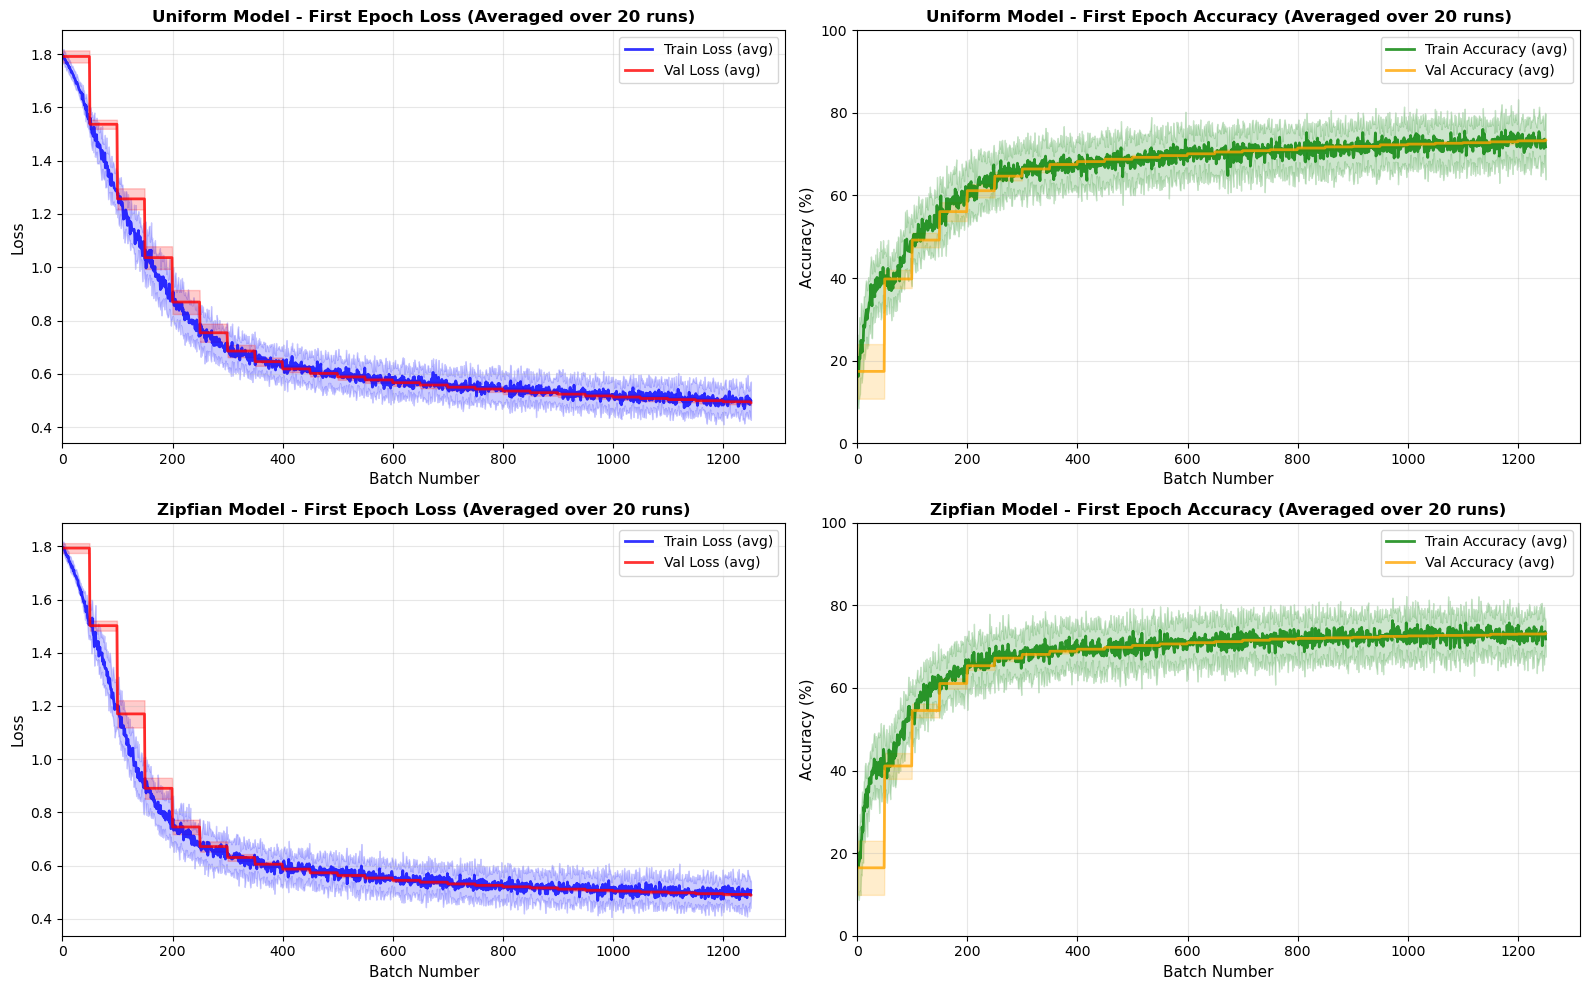


UNIFORM vs ZIPFIAN COMPARISON (Averaged over 20 runs)


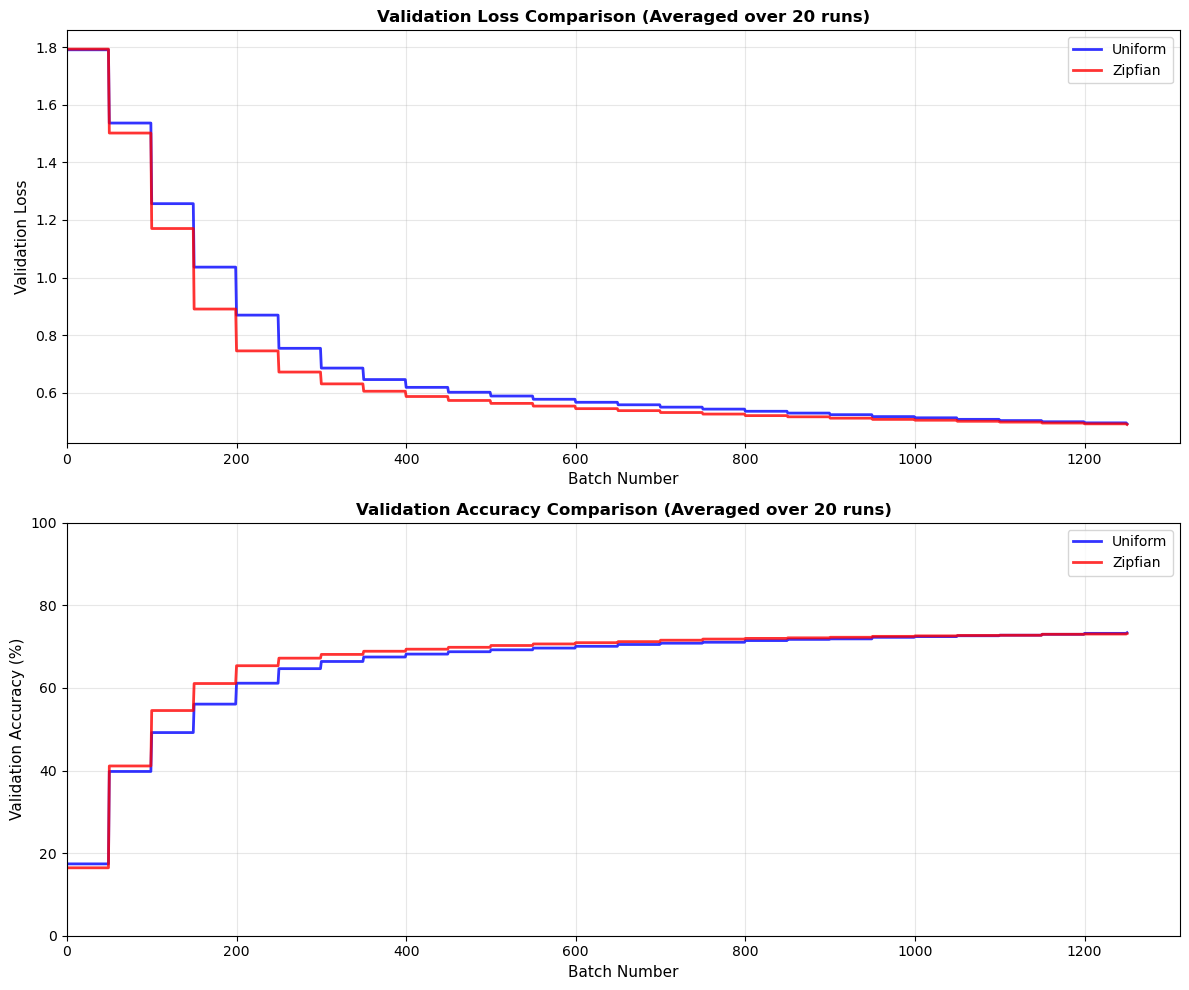

Hyperparameters: embedding_dim=32, hidden_dim=64, num_layers=1, batch_size=64, lr=0.001, epochs=6, dropout=0.2, optimizer=Adam, vocab_size=479, num_classes=6


In [31]:
# Visualization: First epoch batch-level metrics (averaged across runs)
print("\n" + "="*60)
print(f"FIRST EPOCH BATCH-LEVEL METRICS (Averaged across {num_runs} runs)")
print("="*60)

# Compute standard deviations for error bars/bands
def compute_std_metrics(all_results):
    """Compute standard deviation of batch metrics across runs"""
    max_len = max(len(r['first_epoch_batch_train_losses']) for r in all_results)
    
    std_train_losses = np.zeros(max_len)
    std_train_accs = np.zeros(max_len)
    std_val_losses = np.zeros(max_len)
    std_val_accs = np.zeros(max_len)
    counts = np.zeros(max_len)
    
    # First pass: compute means
    means_train_losses = np.zeros(max_len)
    means_train_accs = np.zeros(max_len)
    means_val_losses = np.zeros(max_len)
    means_val_accs = np.zeros(max_len)
    
    for result in all_results:
        train_losses = result['first_epoch_batch_train_losses']
        train_accs = result['first_epoch_batch_train_accs']
        val_losses = result['first_epoch_batch_val_losses']
        val_accs = result['first_epoch_batch_val_accs']
        
        for i in range(len(train_losses)):
            if train_losses[i] is not None:
                means_train_losses[i] += train_losses[i]
                counts[i] += 1
            if train_accs[i] is not None:
                means_train_accs[i] += train_accs[i]
            if i < len(val_losses) and val_losses[i] is not None:
                means_val_losses[i] += val_losses[i]
            if i < len(val_accs) and val_accs[i] is not None:
                means_val_accs[i] += val_accs[i]
    
    means_train_losses = means_train_losses / counts
    means_train_accs = means_train_accs / counts
    means_val_losses = means_val_losses / counts
    means_val_accs = means_val_accs / counts
    
    # Second pass: compute variance
    for result in all_results:
        train_losses = result['first_epoch_batch_train_losses']
        train_accs = result['first_epoch_batch_train_accs']
        val_losses = result['first_epoch_batch_val_losses']
        val_accs = result['first_epoch_batch_val_accs']
        
        for i in range(len(train_losses)):
            if train_losses[i] is not None:
                std_train_losses[i] += (train_losses[i] - means_train_losses[i]) ** 2
            if train_accs[i] is not None:
                std_train_accs[i] += (train_accs[i] - means_train_accs[i]) ** 2
            if i < len(val_losses) and val_losses[i] is not None:
                std_val_losses[i] += (val_losses[i] - means_val_losses[i]) ** 2
            if i < len(val_accs) and val_accs[i] is not None:
                std_val_accs[i] += (val_accs[i] - means_val_accs[i]) ** 2
    
    # Convert to standard deviation
    std_train_losses = np.sqrt(std_train_losses / counts)
    std_train_accs = np.sqrt(std_train_accs / counts)
    std_val_losses = np.sqrt(std_val_losses / counts)
    std_val_accs = np.sqrt(std_val_accs / counts)
    
    return {
        'std_train_losses': std_train_losses,
        'std_train_accs': std_train_accs,
        'std_val_losses': std_val_losses,
        'std_val_accs': std_val_accs
    }

std_uni = compute_std_metrics(all_results_uni)
std_zip = compute_std_metrics(all_results_zip)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Uniform model - Loss
ax = axes[0, 0]
if len(results_uni['first_epoch_batch_train_losses']) > 0:
    batches = np.arange(1, len(results_uni['first_epoch_batch_train_losses']) + 1)
    train_losses = np.array(results_uni['first_epoch_batch_train_losses'])
    val_losses = np.array(results_uni['first_epoch_batch_val_losses'])
    
    ax.plot(batches, train_losses, label='Train Loss (avg)', linewidth=2, alpha=0.8, color='blue')
    ax.fill_between(batches, train_losses - std_uni['std_train_losses'], 
                     train_losses + std_uni['std_train_losses'], alpha=0.2, color='blue')
    ax.plot(batches, val_losses, label='Val Loss (avg)', linewidth=2, alpha=0.8, color='red')
    ax.fill_between(batches, val_losses - std_uni['std_val_losses'], 
                     val_losses + std_uni['std_val_losses'], alpha=0.2, color='red')
    ax.set_xlabel('Batch Number', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title(f'Uniform Model - First Epoch Loss (Averaged over {num_runs} runs)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)

# Uniform model - Accuracy
ax = axes[0, 1]
if len(results_uni['first_epoch_batch_train_accs']) > 0:
    batches = np.arange(1, len(results_uni['first_epoch_batch_train_accs']) + 1)
    train_accs = np.array(results_uni['first_epoch_batch_train_accs'])
    val_accs = np.array(results_uni['first_epoch_batch_val_accs'])
    
    ax.plot(batches, train_accs, label='Train Accuracy (avg)', linewidth=2, alpha=0.8, color='green')
    ax.fill_between(batches, train_accs - std_uni['std_train_accs'], 
                     train_accs + std_uni['std_train_accs'], alpha=0.2, color='green')
    ax.plot(batches, val_accs, label='Val Accuracy (avg)', linewidth=2, alpha=0.8, color='orange')
    ax.fill_between(batches, val_accs - std_uni['std_val_accs'], 
                     val_accs + std_uni['std_val_accs'], alpha=0.2, color='orange')
    ax.set_xlabel('Batch Number', fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(f'Uniform Model - First Epoch Accuracy (Averaged over {num_runs} runs)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0, top=100)

# Zipfian model - Loss
ax = axes[1, 0]
if len(results_zip['first_epoch_batch_train_losses']) > 0:
    batches = np.arange(1, len(results_zip['first_epoch_batch_train_losses']) + 1)
    train_losses = np.array(results_zip['first_epoch_batch_train_losses'])
    val_losses = np.array(results_zip['first_epoch_batch_val_losses'])
    
    ax.plot(batches, train_losses, label='Train Loss (avg)', linewidth=2, alpha=0.8, color='blue')
    ax.fill_between(batches, train_losses - std_zip['std_train_losses'], 
                     train_losses + std_zip['std_train_losses'], alpha=0.2, color='blue')
    ax.plot(batches, val_losses, label='Val Loss (avg)', linewidth=2, alpha=0.8, color='red')
    ax.fill_between(batches, val_losses - std_zip['std_val_losses'], 
                     val_losses + std_zip['std_val_losses'], alpha=0.2, color='red')
    ax.set_xlabel('Batch Number', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title(f'Zipfian Model - First Epoch Loss (Averaged over {num_runs} runs)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)

# Zipfian model - Accuracy
ax = axes[1, 1]
if len(results_zip['first_epoch_batch_train_accs']) > 0:
    batches = np.arange(1, len(results_zip['first_epoch_batch_train_accs']) + 1)
    train_accs = np.array(results_zip['first_epoch_batch_train_accs'])
    val_accs = np.array(results_zip['first_epoch_batch_val_accs'])
    
    ax.plot(batches, train_accs, label='Train Accuracy (avg)', linewidth=2, alpha=0.8, color='green')
    ax.fill_between(batches, train_accs - std_zip['std_train_accs'], 
                     train_accs + std_zip['std_train_accs'], alpha=0.2, color='green')
    ax.plot(batches, val_accs, label='Val Accuracy (avg)', linewidth=2, alpha=0.8, color='orange')
    ax.fill_between(batches, val_accs - std_zip['std_val_accs'], 
                     val_accs + std_zip['std_val_accs'], alpha=0.2, color='orange')
    ax.set_xlabel('Batch Number', fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(f'Zipfian Model - First Epoch Accuracy (Averaged over {num_runs} runs)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0, top=100)

plt.tight_layout()
plt.show()

# Overlay plot: Uniform vs Zipfian comparison (2x1 layout)
print(f"\n{'='*60}")
print(f"UNIFORM vs ZIPFIAN COMPARISON (Averaged over {num_runs} runs)")
print(f"{'='*60}")

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Loss comparison (top plot)
ax = axes[0]
if len(results_uni['first_epoch_batch_val_losses']) > 0 and len(results_zip['first_epoch_batch_val_losses']) > 0:
    batches_uni = np.arange(1, len(results_uni['first_epoch_batch_val_losses']) + 1)
    batches_zip = np.arange(1, len(results_zip['first_epoch_batch_val_losses']) + 1)
    
    val_losses_uni = np.array(results_uni['first_epoch_batch_val_losses'])
    val_losses_zip = np.array(results_zip['first_epoch_batch_val_losses'])
    
    ax.plot(batches_uni, val_losses_uni, label='Uniform', linewidth=2, alpha=0.8, color='blue')
    ax.plot(batches_zip, val_losses_zip, label='Zipfian', linewidth=2, alpha=0.8, color='red')
    ax.set_xlabel('Batch Number', fontsize=11)
    ax.set_ylabel('Validation Loss', fontsize=11)
    ax.set_title(f'Validation Loss Comparison (Averaged over {num_runs} runs)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)

# Accuracy comparison (bottom plot)
ax = axes[1]
if len(results_uni['first_epoch_batch_val_accs']) > 0 and len(results_zip['first_epoch_batch_val_accs']) > 0:
    batches_uni = np.arange(1, len(results_uni['first_epoch_batch_val_accs']) + 1)
    batches_zip = np.arange(1, len(results_zip['first_epoch_batch_val_accs']) + 1)
    
    val_accs_uni = np.array(results_uni['first_epoch_batch_val_accs'])
    val_accs_zip = np.array(results_zip['first_epoch_batch_val_accs'])
    
    ax.plot(batches_uni, val_accs_uni, label='Uniform', linewidth=2, alpha=0.8, color='blue')
    ax.plot(batches_zip, val_accs_zip, label='Zipfian', linewidth=2, alpha=0.8, color='red')
    ax.set_xlabel('Batch Number', fontsize=11)
    ax.set_ylabel('Validation Accuracy (%)', fontsize=11)
    ax.set_title(f'Validation Accuracy Comparison (Averaged over {num_runs} runs)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0, top=100)

plt.tight_layout()
plt.show()

print(f"Hyperparameters: embedding_dim=32, hidden_dim=64, num_layers=1, batch_size=64, lr=0.001, epochs=6, dropout=0.2, optimizer=Adam, vocab_size={vocab_size}, num_classes={num_classes}")

In [ ]:
# Evaluation function
def evaluate_model(model, val_loader, model_name="model"):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    
    # Classification report
    class_names = [idx_to_class[i] for i in range(len(class_to_idx))]
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    return {
        'accuracy': accuracy,
        'report': report,
        'confusion_matrix': cm,
        'predictions': all_preds,
        'labels': all_labels
    }

# Evaluate both models
print("\n" + "="*60)
print("EVALUATION RESULTS")
print("="*60)

eval_uni = evaluate_model(model_uni, val_loader_uni, "Uniform Model")
eval_zip = evaluate_model(model_zip, val_loader_zip, "Zipfian Model")

print(f"\nUniform Distribution Model:")
print(f"  Accuracy: {eval_uni['accuracy']*100:.2f}%")
print(f"\nZipfian Distribution Model:")
print(f"  Accuracy: {eval_zip['accuracy']*100:.2f}%")

# Detailed classification reports
print(f"\n{'='*60}")
print("DETAILED CLASSIFICATION REPORT - UNIFORM MODEL")
print(f"{'='*60}")
class_names = [idx_to_class[i] for i in range(len(class_to_idx))]
for class_name in class_names:
    if class_name in eval_uni['report']:
        metrics = eval_uni['report'][class_name]
        print(f"\n{class_name}:")
        print(f"  Precision: {metrics['precision']:.3f}")
        print(f"  Recall: {metrics['recall']:.3f}")
        print(f"  F1-score: {metrics['f1-score']:.3f}")
        print(f"  Support: {int(metrics['support'])}")

print(f"\n{'='*60}")
print("DETAILED CLASSIFICATION REPORT - ZIPFIAN MODEL")
print(f"{'='*60}")
for class_name in class_names:
    if class_name in eval_zip['report']:
        metrics = eval_zip['report'][class_name]
        print(f"\n{class_name}:")
        print(f"  Precision: {metrics['precision']:.3f}")
        print(f"  Recall: {metrics['recall']:.3f}")
        print(f"  F1-score: {metrics['f1-score']:.3f}")
        print(f"  Support: {int(metrics['support'])}")



EVALUATION RESULTS

Uniform Distribution Model:
  Accuracy: 70.90%

Zipfian Distribution Model:
  Accuracy: 70.86%

DETAILED CLASSIFICATION REPORT - UNIFORM MODEL

Adj:
  Precision: 0.497
  Recall: 0.505
  F1-score: 0.501
  Support: 3370

Det:
  Precision: 0.801
  Recall: 0.881
  F1-score: 0.839
  Support: 7142

N:
  Precision: 0.671
  Recall: 0.663
  F1-score: 0.667
  Support: 5125

OTHER:
  Precision: 0.202
  Recall: 0.121
  F1-score: 0.152
  Support: 1779

P:
  Precision: 0.994
  Recall: 0.996
  F1-score: 0.995
  Support: 1735

V:
  Precision: 0.993
  Recall: 0.994
  F1-score: 0.994
  Support: 849

DETAILED CLASSIFICATION REPORT - ZIPFIAN MODEL

Adj:
  Precision: 0.499
  Recall: 0.490
  F1-score: 0.494
  Support: 3381

Det:
  Precision: 0.797
  Recall: 0.885
  F1-score: 0.839
  Support: 7156

N:
  Precision: 0.667
  Recall: 0.675
  F1-score: 0.671
  Support: 5123

OTHER:
  Precision: 0.184
  Recall: 0.104
  F1-score: 0.133
  Support: 1795

P:
  Precision: 0.999
  Recall: 0.999
  F1

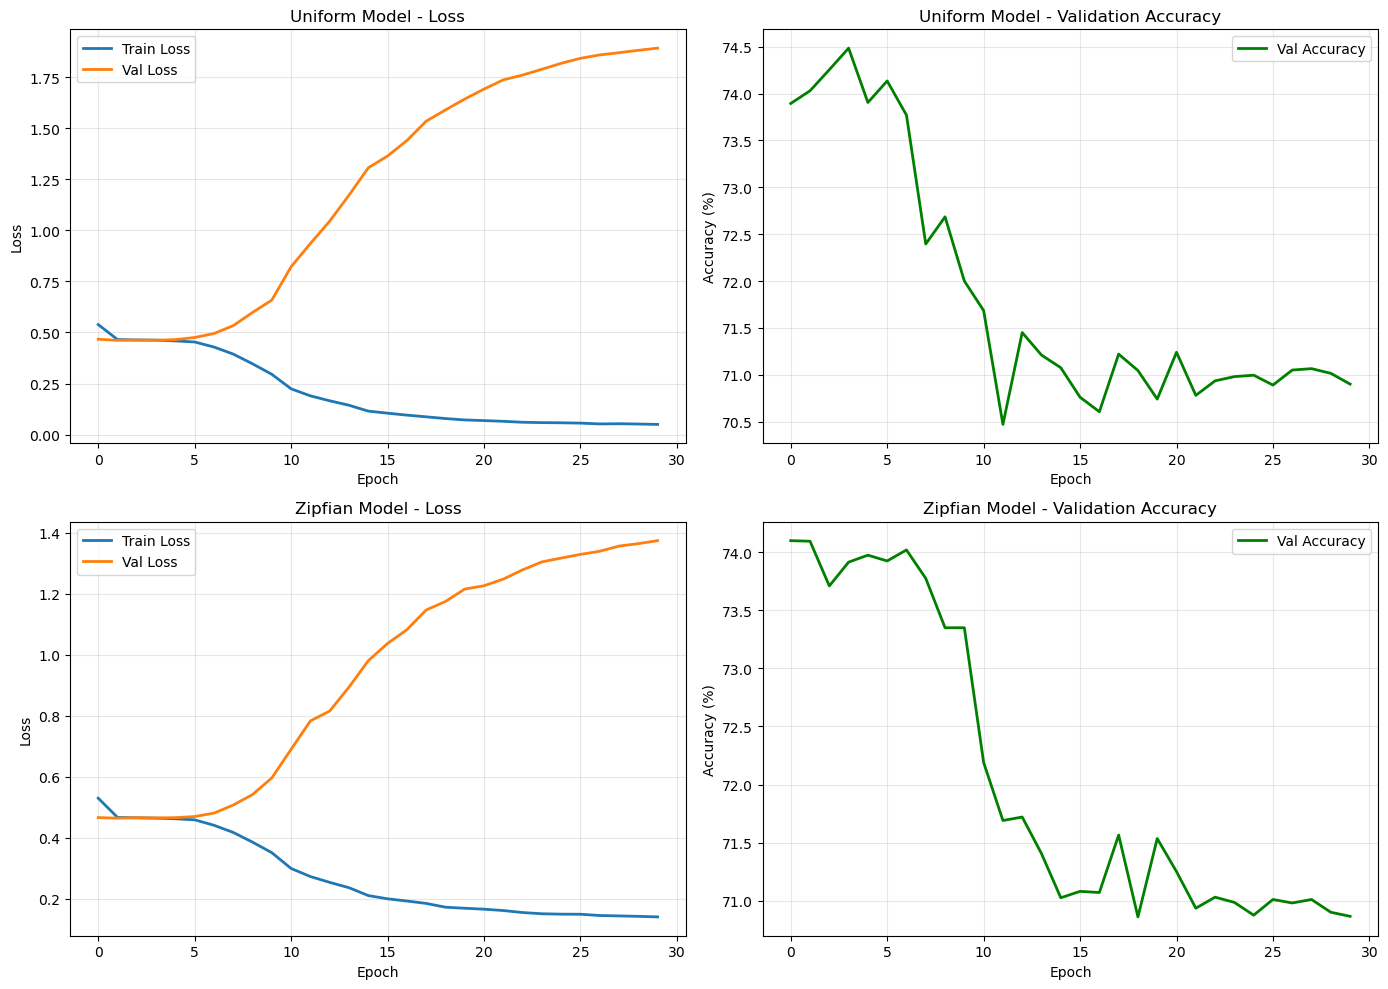

In [ ]:
# Visualization: Training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Uniform model
axes[0, 0].plot(results_uni['train_losses'], label='Train Loss', linewidth=2)
axes[0, 0].plot(results_uni['val_losses'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Uniform Model - Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(results_uni['val_accuracies'], label='Val Accuracy', linewidth=2, color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Uniform Model - Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Zipfian model
axes[1, 0].plot(results_zip['train_losses'], label='Train Loss', linewidth=2)
axes[1, 0].plot(results_zip['val_losses'], label='Val Loss', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Zipfian Model - Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(results_zip['val_accuracies'], label='Val Accuracy', linewidth=2, color='green')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Zipfian Model - Validation Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Word Class Prediction with LLM

This notebook trains a language model to predict word classes (Adj, N, V, etc.) given the previous n-1 words in a sentence.

We'll:
1. Generate synthetic text with grammatical structure (no semantic meaning)
2. Split data into uniform and zipfian distributions
3. Train two models (one for each distribution)
4. Evaluate performance with metrics


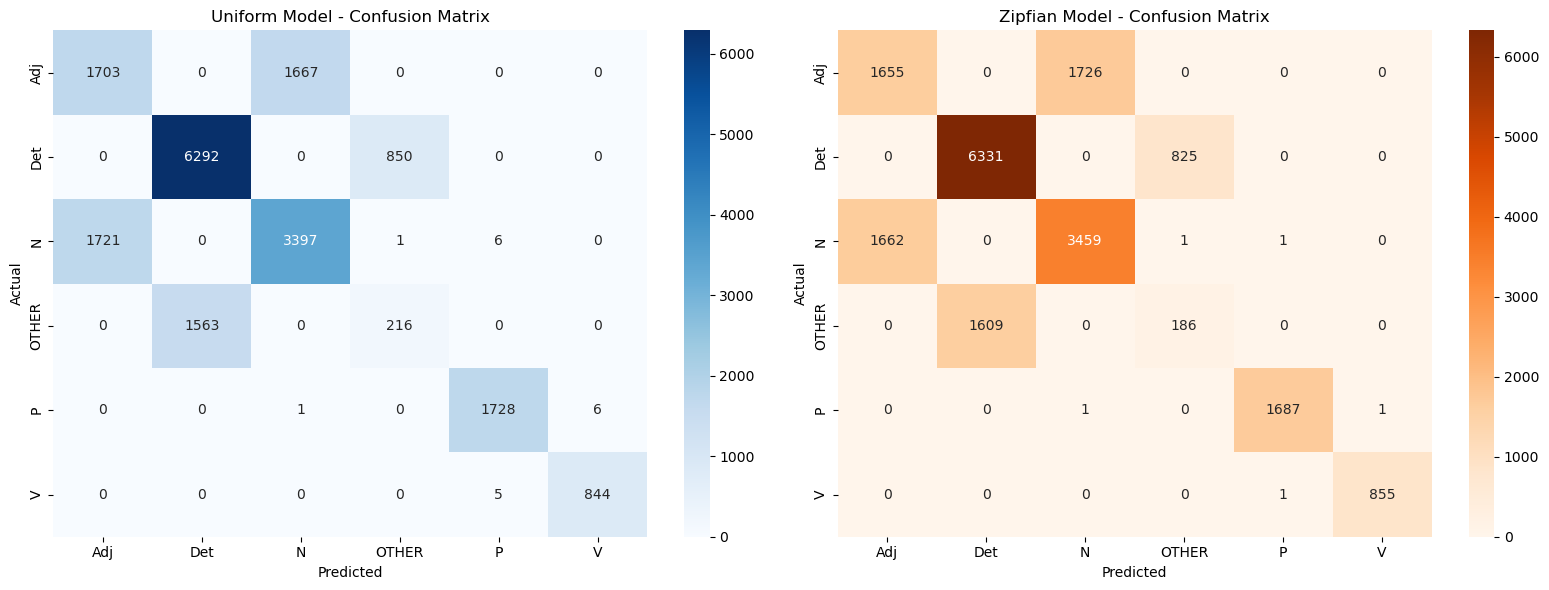

In [ ]:
# Visualization: Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

class_names = [idx_to_class[i] for i in range(len(class_to_idx))]

# Uniform model confusion matrix
sns.heatmap(eval_uni['confusion_matrix'], annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Uniform Model - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Zipfian model confusion matrix
sns.heatmap(eval_zip['confusion_matrix'], annot=True, fmt='d', cmap='Oranges', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Zipfian Model - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [ ]:
# Comparison metrics
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

print(f"\n{'Metric':<30} {'Uniform Model':<20} {'Zipfian Model':<20}")
print("-" * 70)
print(f"{'Overall Accuracy':<30} {eval_uni['accuracy']*100:>18.2f}% {eval_zip['accuracy']*100:>18.2f}%")
print(f"{'Best Val Accuracy':<30} {results_uni['best_val_acc']:>18.2f}% {results_zip['best_val_acc']:>18.2f}%")
print(f"{'Macro Avg Precision':<30} {eval_uni['report']['macro avg']['precision']:>18.3f} {eval_zip['report']['macro avg']['precision']:>18.3f}")
print(f"{'Macro Avg Recall':<30} {eval_uni['report']['macro avg']['recall']:>18.3f} {eval_zip['report']['macro avg']['recall']:>18.3f}")
print(f"{'Macro Avg F1-Score':<30} {eval_uni['report']['macro avg']['f1-score']:>18.3f} {eval_zip['report']['macro avg']['f1-score']:>18.3f}")
print(f"{'Weighted Avg Precision':<30} {eval_uni['report']['weighted avg']['precision']:>18.3f} {eval_zip['report']['weighted avg']['precision']:>18.3f}")
print(f"{'Weighted Avg Recall':<30} {eval_uni['report']['weighted avg']['recall']:>18.3f} {eval_zip['report']['weighted avg']['recall']:>18.3f}")
print(f"{'Weighted Avg F1-Score':<30} {eval_uni['report']['weighted avg']['f1-score']:>18.3f} {eval_zip['report']['weighted avg']['f1-score']:>18.3f}")

# Per-class comparison
print(f"\n{'='*60}")
print("PER-CLASS PERFORMANCE COMPARISON")
print("="*60)
print(f"\n{'Class':<10} {'Metric':<12} {'Uniform':<12} {'Zipfian':<12} {'Difference':<12}")
print("-" * 60)

for class_name in class_names:
    if class_name in eval_uni['report'] and class_name in eval_zip['report']:
        uni_f1 = eval_uni['report'][class_name]['f1-score']
        zip_f1 = eval_zip['report'][class_name]['f1-score']
        diff = uni_f1 - zip_f1
        print(f"{class_name:<10} {'F1-Score':<12} {uni_f1:>11.3f} {zip_f1:>11.3f} {diff:>+11.3f}")
        
        uni_prec = eval_uni['report'][class_name]['precision']
        zip_prec = eval_zip['report'][class_name]['precision']
        diff_prec = uni_prec - zip_prec
        print(f"{'':<10} {'Precision':<12} {uni_prec:>11.3f} {zip_prec:>11.3f} {diff_prec:>+11.3f}")
        
        uni_rec = eval_uni['report'][class_name]['recall']
        zip_rec = eval_zip['report'][class_name]['recall']
        diff_rec = uni_rec - zip_rec
        print(f"{'':<10} {'Recall':<12} {uni_rec:>11.3f} {zip_rec:>11.3f} {diff_rec:>+11.3f}")
        print()



MODEL COMPARISON SUMMARY

Metric                         Uniform Model        Zipfian Model       
----------------------------------------------------------------------
Overall Accuracy                            70.90%              70.86%
Best Val Accuracy                           74.48%              74.10%
Macro Avg Precision                         0.693              0.691
Macro Avg Recall                            0.693              0.692
Macro Avg F1-Score                          0.691              0.689
Weighted Avg Precision                      0.688              0.684
Weighted Avg Recall                         0.709              0.709
Weighted Avg F1-Score                       0.697              0.695

PER-CLASS PERFORMANCE COMPARISON

Class      Metric       Uniform      Zipfian      Difference  
------------------------------------------------------------
Adj        F1-Score           0.501       0.494      +0.007
           Precision          0.497       0.499      -

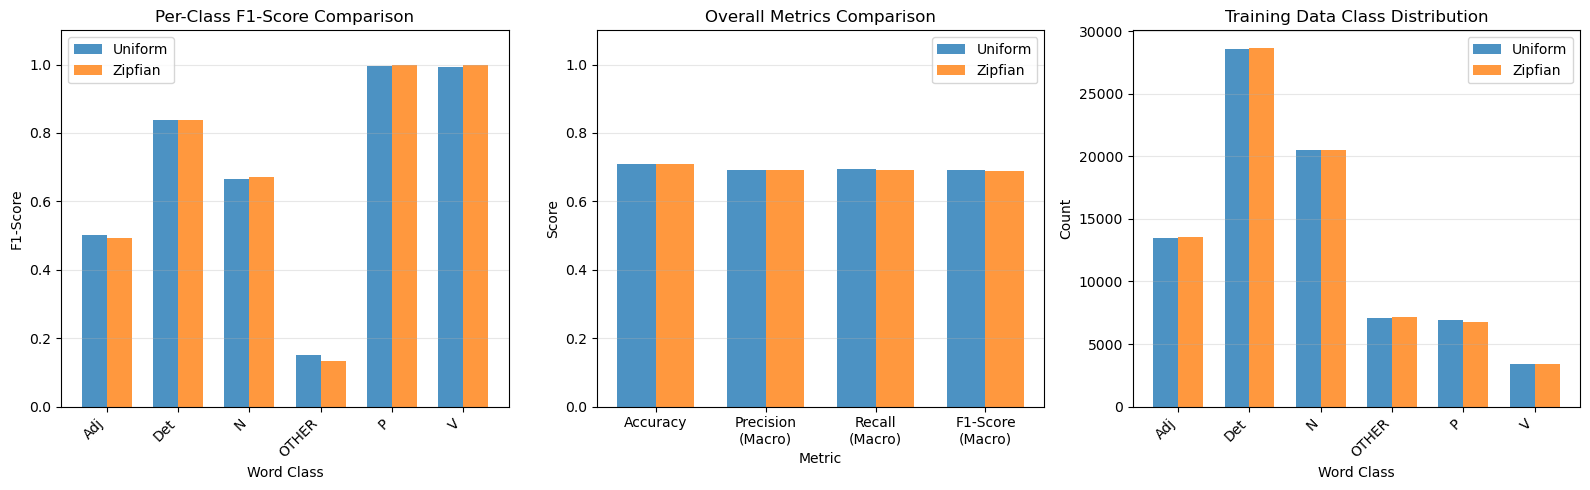

In [ ]:
# Visual comparison of metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Per-class F1 scores
class_names = [idx_to_class[i] for i in range(len(class_to_idx))]
uni_f1_scores = [eval_uni['report'][cls]['f1-score'] if cls in eval_uni['report'] else 0 for cls in class_names]
zip_f1_scores = [eval_zip['report'][cls]['f1-score'] if cls in eval_zip['report'] else 0 for cls in class_names]

x = np.arange(len(class_names))
width = 0.35

axes[0].bar(x - width/2, uni_f1_scores, width, label='Uniform', alpha=0.8)
axes[0].bar(x + width/2, zip_f1_scores, width, label='Zipfian', alpha=0.8)
axes[0].set_xlabel('Word Class')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('Per-Class F1-Score Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 1.1])

# Overall metrics comparison
metrics = ['Accuracy', 'Precision\n(Macro)', 'Recall\n(Macro)', 'F1-Score\n(Macro)']
uni_metrics = [
    eval_uni['accuracy'],
    eval_uni['report']['macro avg']['precision'],
    eval_uni['report']['macro avg']['recall'],
    eval_uni['report']['macro avg']['f1-score']
]
zip_metrics = [
    eval_zip['accuracy'],
    eval_zip['report']['macro avg']['precision'],
    eval_zip['report']['macro avg']['recall'],
    eval_zip['report']['macro avg']['f1-score']
]

x2 = np.arange(len(metrics))
axes[1].bar(x2 - width/2, uni_metrics, width, label='Uniform', alpha=0.8)
axes[1].bar(x2 + width/2, zip_metrics, width, label='Zipfian', alpha=0.8)
axes[1].set_xlabel('Metric')
axes[1].set_ylabel('Score')
axes[1].set_title('Overall Metrics Comparison')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(metrics)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([0, 1.1])

# Training data distribution comparison
uni_train_class_dist = [uni_train_counts.get(i, 0) for i in range(len(class_to_idx))]
zip_train_class_dist = [zip_train_counts.get(i, 0) for i in range(len(class_to_idx))]

axes[2].bar(x - width/2, uni_train_class_dist, width, label='Uniform', alpha=0.8)
axes[2].bar(x + width/2, zip_train_class_dist, width, label='Zipfian', alpha=0.8)
axes[2].set_xlabel('Word Class')
axes[2].set_ylabel('Count')
axes[2].set_title('Training Data Class Distribution')
axes[2].set_xticks(x)
axes[2].set_xticklabels(class_names, rotation=45, ha='right')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
